# Línea de base v2

## ResNet18 para Espectrogramas (128 Mel bins)

In [1]:
%%capture
from framework.framework_final import Persister, MetricsCalculator, AudioResNetModel, GSC, Preprocessor, Trainer, Evaluator, prepare_batch, plot_curves, show_image_grid, signal_grad_cam_overlays2d
from pathlib import Path
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import numpy as np
from typing import List, Dict, Any, Optional
import pandas as pd
from sklearn.preprocessing import LabelEncoder

I0000 00:00:1780889254.582161    2082 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780889254.613217    2082 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780889255.433139    2082 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780889255.433398    2082 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
AUDIO_PATH = Path('/mnt/data/GSC/normalized-dataset')
XTRAIN_PATH = Path('./dataframes/FASE2-X_train.csv')
XTEST_PATH = Path('./dataframes/FASE2-X_test.csv')
XVAL_PATH = Path('./dataframes/FASE2-X_val.csv')
YVAL_PATH = Path('./dataframes/FASE2-y_val.csv')
YTRAIN_PATH = Path('./dataframes/FASE2-y_train.csv')
YTEST_PATH = Path('./dataframes/FASE2-y_test.csv')
BACKGROUND_NOISES = sorted(Path(f"/mnt/data/GSC/speech_commands_v0.02/_background_noise_/").glob('*wav'))

NUM_CLASSES = 35

DEVICE = 'cuda'

# Cambios MELs
SAMPLE_RATE = 16000
N_MELS =128
N_FFT = int(768)
WIN_LENGTH = N_FFT
HOP_LENGTH = int(100)

In [3]:
final_path = '00-baseline_resnet18_02/final'
checkpoints_path = '00-baseline_resnet18_02/checkpoints'
xai_path = Path('/mnt/data/GSC/XAI/00-baseline_resnet18_02')
batch_size = 224
epochs = 10

In [4]:
%%capture
# Instanciación del framework
persister = Persister(final_path=final_path, checkpoints_path=checkpoints_path, xai_path=xai_path)
preprocessor_train = Preprocessor(
        sample_rate = SAMPLE_RATE,
        n_mels = N_MELS,
        win_length = WIN_LENGTH,
        hop_length = HOP_LENGTH,
        n_fft = N_FFT,    
        with_log = True,
        device = DEVICE,
        mode = "training")

preprocessor_test = Preprocessor(
        sample_rate = SAMPLE_RATE,
        n_mels = N_MELS,
        win_length = WIN_LENGTH,
        hop_length = HOP_LENGTH,
        n_fft = N_FFT,    
        with_log = True,
        device = DEVICE)
# Modelo
model = AudioResNetModel(dims=2, num_classes=NUM_CLASSES).get_model()
model.to(DEVICE)

In [5]:
# Conjuntos de datos
X_train = pd.read_csv(XTRAIN_PATH)
X_test = pd.read_csv(XTEST_PATH)
y_train = pd.read_csv(YTRAIN_PATH)
y_test = pd.read_csv(YTRAIN_PATH)
X_val = pd.read_csv(XVAL_PATH)                                                                                                          
y_val = pd.read_csv(YVAL_PATH)                                                                                                          

le = LabelEncoder()

y_encoded = le.fit_transform(y_train['keyword'])
ytest_encoded = le.transform(y_test['keyword'])
yval_encoded = le.transform(y_val['keyword'])

label_names= le.classes_

train_list = X_train['path_normalized'].tolist()                                                                                            
train_labels = y_encoded.tolist() 
val_list = X_val['path_normalized'].tolist()                                                                                            
val_labels = yval_encoded.tolist() 
test_list = X_test['path_normalized'].tolist()
test_labels = ytest_encoded.tolist()

train_dataset = GSC(file_list=train_list, labels=train_labels)
validation_dataset = GSC(file_list=val_list, labels=val_labels)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=prepare_batch, num_workers=4)
val_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False, collate_fn=prepare_batch, num_workers=4)
test_dataset = GSC(test_list, test_labels)
test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False, collate_fn = prepare_batch, num_workers = 4)

In [6]:
trainer = Trainer(model=model, train_loader=train_loader, val_loader=val_loader, preprocessor=preprocessor_train, persister=persister, device=DEVICE, epochs=10)                        
trainer.fit(resume=True)

Epoch::   0%|          | 0/10 [00:00<?, ?it/s]

Batches entrenamiento:   0%|          | 0/331 [00:00<?, ?it/s]

Batches validación:   0%|          | 0/48 [00:00<?, ?it/s]

Epoch 1/10
  Train - Pérdida: 0.6881, Accuracy: 0.8037, F1-score: 0.7956
  Val   - Pérdida: 0.4710, Accuracy: 0.8550, F1-score: 0.8491


Batches entrenamiento:   0%|          | 0/331 [00:00<?, ?it/s]

...

Batches validación:   0%|          | 0/48 [00:00<?, ?it/s]

Epoch 9/10
  Train - Pérdida: 0.0493, Accuracy: 0.9850, F1-score: 0.9837
  Val   - Pérdida: 0.4262, Accuracy: 0.9059, F1-score: 0.8998


Batches entrenamiento:   0%|          | 0/331 [00:00<?, ?it/s]

Batches validación:   0%|          | 0/48 [00:00<?, ?it/s]

Epoch 10/10
  Train - Pérdida: 0.0471, Accuracy: 0.9850, F1-score: 0.9837
  Val   - Pérdida: 0.3295, Accuracy: 0.9258, F1-score: 0.9211


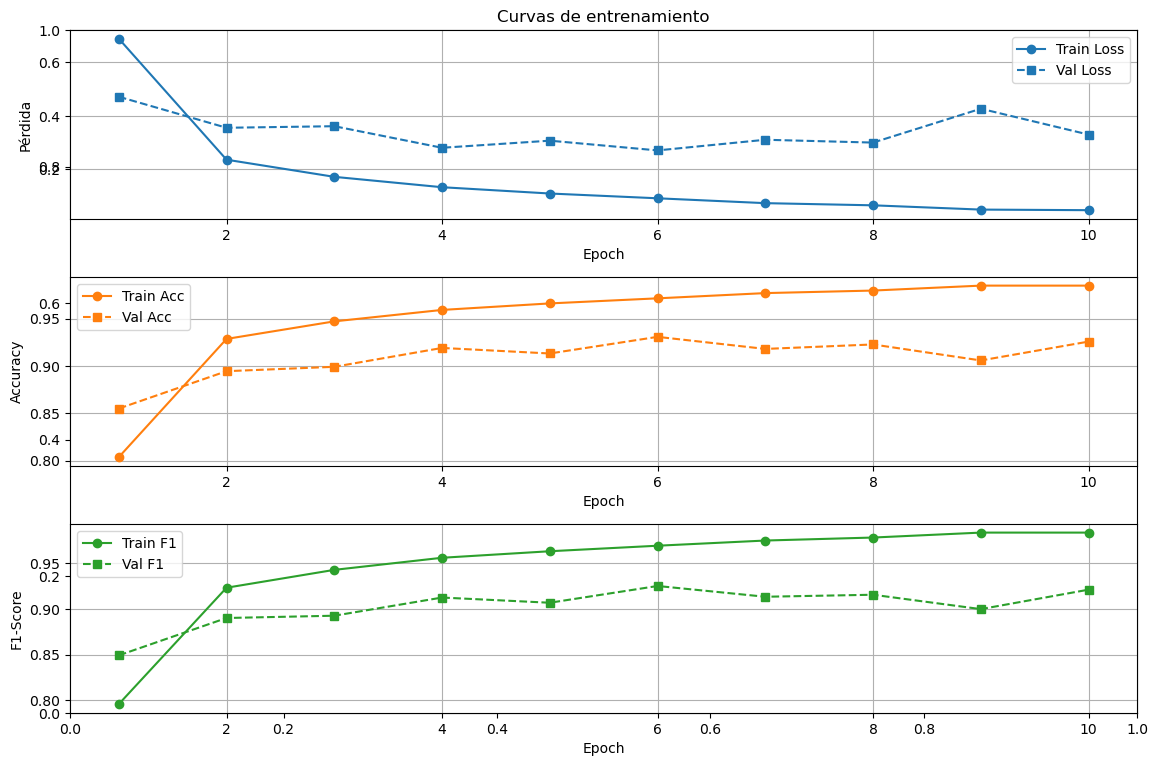

In [6]:
# Evaluación del modelo
# Cargamos desde el disco para poder evaluar en cualquier momento
loaded_pt = torch.load(f"{final_path}/final_model.pt", map_location=DEVICE)
loaded_model = AudioResNetModel(dims=2, num_classes=35).get_model()
loaded_model.load_state_dict(loaded_pt['model_state_dict'])
loaded_model.eval()

plot_curves(loaded_pt, 'Curvas de entrenamiento')

**Análisis del entrenamiento**

Las métricas de accuracy y f1 con esta representación de espectrogramas  mejoran la línea de base anterior. La evolución de las curvas de validación indican cierto estancamiento en la generalización del aprendizaje a partir de la epoch 6.

In [7]:
# Evaluación del modelo
# Cargamos desde el disco para poder evaluar en cualquier momento
loaded_pt = torch.load(f"{final_path}/final_model.pt", map_location=DEVICE)
loaded_model = AudioResNetModel(dims=2, num_classes=35).get_model()
loaded_model.load_state_dict(loaded_pt['model_state_dict'])
loaded_model.eval()

# Instanciamos el evaluador y computamos métricas
evaluator = Evaluator(model=loaded_model, device=DEVICE, test_loader=test_loader, preprocessor = preprocessor_test)
confusion_matrix, precission, recall, avg_loss, accuracy, f1, support = evaluator.eval()
print("Pérdida:", avg_loss, "Accuracy:", accuracy, "F1-Score:", f1)

Batches evaluación:   0%|          | 0/48 [00:00<?, ?it/s]

Pérdida: 0.7708345371261703 Accuracy: 0.9028539028539029 F1-Score: 0.8987722210687261


Las métricas son mejores en general con esta representación de espectrogramas.

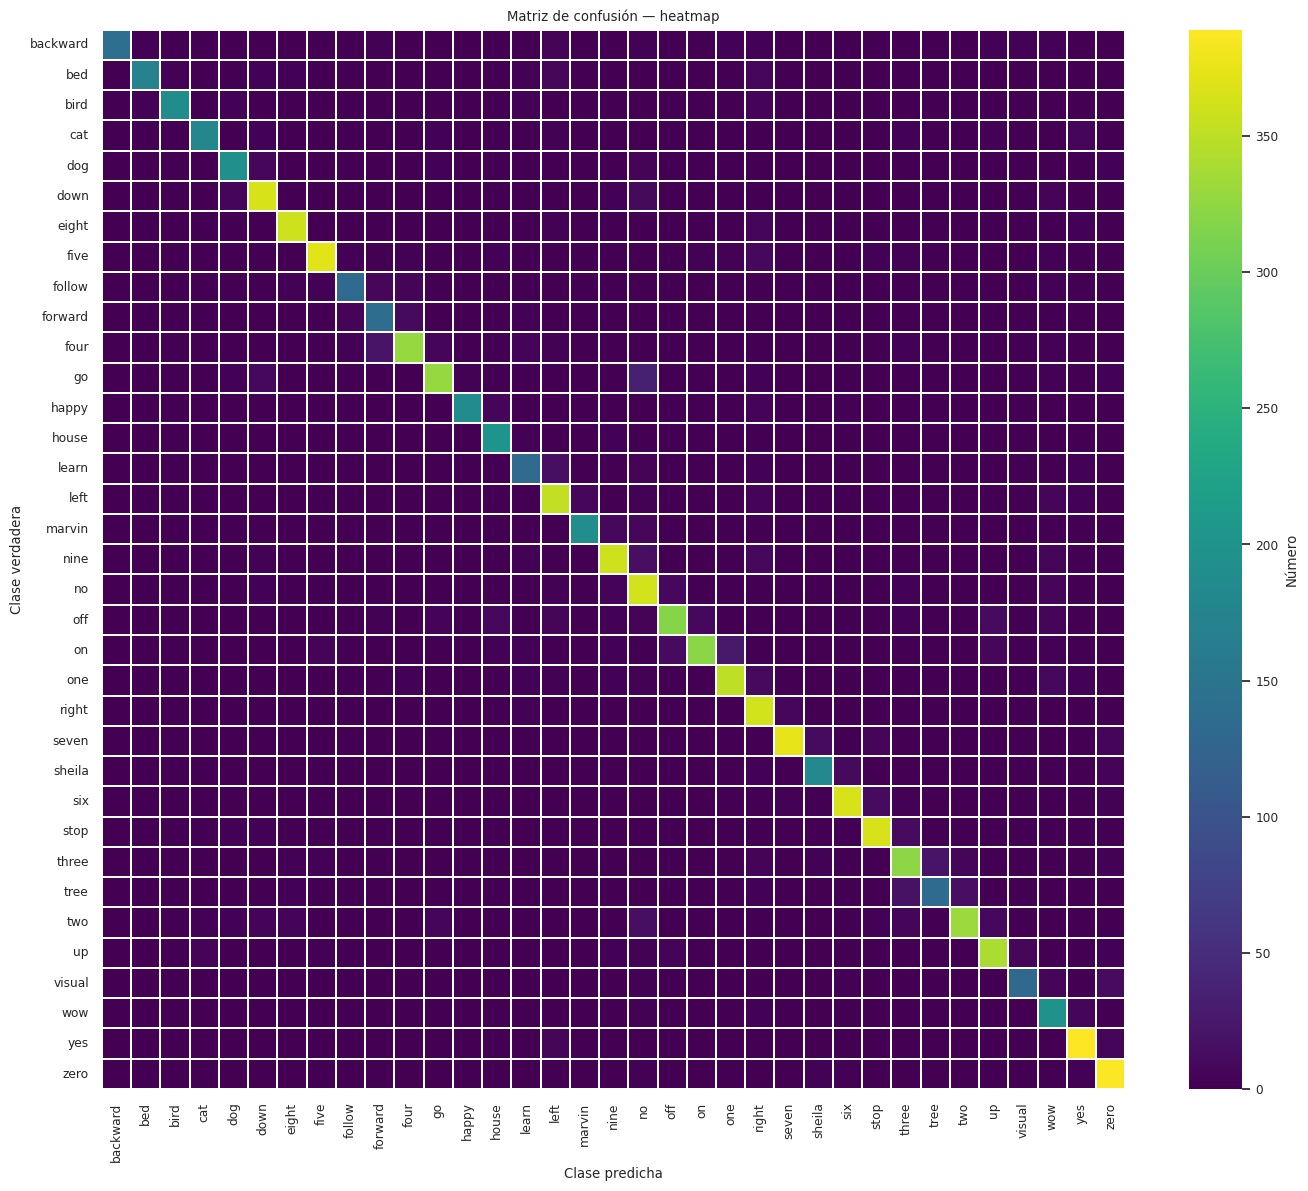

In [8]:
import matplotlib.pyplot as plt
import seaborn as sb

plt.figure(figsize = (14,12))
sb.set(font_scale = 0.8)
ax = sb.heatmap(confusion_matrix,
                annot=False,
                fmt = ".2f",
                cmap = "viridis",
                cbar_kws = {"label": "Número"},
                xticklabels = label_names,
                yticklabels = label_names,
                linewidths = 0.3,
                linecolor = "white")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.xlabel("Clase predicha")
plt.ylabel("Clase verdadera")
plt.title("Matriz de confusión — heatmap")
plt.tight_layout()
plt.show()
plt.rcdefaults()

En este caso, hay cierta concentración de confusiones entra las clases "no" y "go".

In [10]:
print("Accuracy:", accuracy, "Precission:", precission, "Recall:", recall, "Pérdida media:", avg_loss, "F1-score:", f1)

Accuracy: 0.9028539028539029 Precission: 0.9047505511786588 Recall: 0.8959800560649148 Pérdida media: 0.7708345371261703 F1-score: 0.8987722210687261


In [11]:
results = evaluator.eval_samples()
right = results[results['predicción'] == results['real']]
wrong = results[results['predicción'] != results['real']]

# Observaciones de la certeza del modelo
print("Número de errores:", wrong['path'].count(), "Porcentaje del total:", wrong['path'].count()*100/results['path'].count(), "%")

print("Aciertos: margen entre 2 opciones más probables - media:", right['margen'].mean())
print("Aciertos: margen entre 2 opciones más probables - primer cuartil:", right['margen'].quantile(0.25))

print("Errores: margen entre 2 opciones más probables - media:",  wrong['margen'].median())
print("Errores: margen entre 2 opciones más probables - tercer cuartil:", wrong['margen'].quantile(0.75))

Número de errores: 1028 Porcentaje del total: 9.714609714609715 %
Aciertos: margen entre 2 opciones más probables - media: 0.97337174
Aciertos: margen entre 2 opciones más probables - primer cuartil: 0.9996620565652847
Errores: margen entre 2 opciones más probables - media: 0.7186886
Errores: margen entre 2 opciones más probables - tercer cuartil: 0.9841247648000717


Vemos que el porcentaje de errores disminuye significativamente.

Vamos a profundizar en el estudio de estas cuestiones y comenzaremos por visualizar algunos de los espectrogramas que hemos preparado para el modelo, para hacernos una idea del punto de partida.

In [9]:
# Dataloaders para estudio
wrong_dataset = GSC(wrong['path'].tolist(), wrong['real'].tolist())
wrong_dataloader = DataLoader(wrong_dataset, batch_size = batch_size, shuffle = False, collate_fn = prepare_batch, num_workers = 6)

few_samples_dataset = GSC(wrong['path'].tolist()[:9], wrong['real'].tolist()[:9])
few_samples_dataloader = DataLoader(few_samples_dataset, batch_size = batch_size, shuffle = False, collate_fn = prepare_batch, num_workers = 6)

Vamos a graficar los ejemplos que hemos seleccionado en la primera línea de base para graficar las diferencias.

Vamos a visualizar también los espectrogramas con HiResCAM para ver si nos puede dar más información.

Se observa que la diferencia en la importancia del gradiente en la parte central no es poco significativa, pero a efectos prácticos ambos algoritmos nos muestran una información parecida. 

Vamos a usar esta misma técnica para exploramos de la misma manera las diferencias entre la clase UP y la predicción OFF. Para valorar el error. Hay que tener en cuenta que la confianza del modelo en la decisión es baja en esta muestra, lo que es un dato positivo con respecto a la coherencia de la respuesta.

In [12]:
## Signal_grad_cam: Preparamos los datos
reference_samples = ['/mnt/data/GSC/normalized-dataset/go/012c8314_nohash_0.wav',
                    '/mnt/data/GSC/normalized-dataset/off/0227998e_nohash_0.wav',
                    '/mnt/data/GSC/normalized-dataset/left/016e2c6d_nohash_0.wav']
reference_labels = [11,19,15]

reference_dataset = GSC(reference_samples, reference_labels)
reference_loader = DataLoader(reference_dataset, batch_size = 3, shuffle = False, 
                              collate_fn = prepare_batch, num_workers = 4)

reference_targets = [11,19,15]

In [13]:
%%capture
## Generamos los CAMs
target_layers = ['layer4.1.conv2', 'layer4.0.conv2', 
                 'layer3.1.conv2', 'layer3.0.conv2', 
                 'layer2.1.conv2', 'layer1.1.conv2']

explainer = "Grad-CAM"

signal_grad_cam_overlays2d(model=loaded_model, dataloader=reference_loader, preprocessor=preprocessor_test,
                          xai_path=xai_path, label_names=label_names, explainer=explainer,
                          target_layers=target_layers, target_classes=reference_labels, 
                          targets_list=reference_targets)

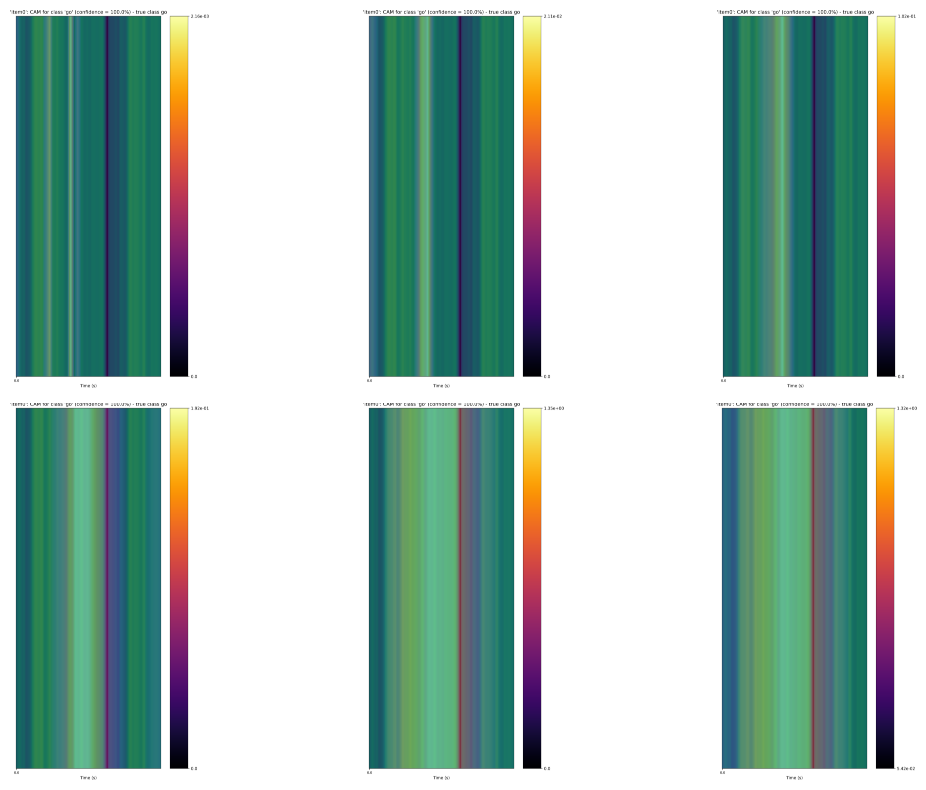

In [14]:
## Visualizamos
# "GO"
images_to_show = sorted(Path(f"{xai_path}/CAMs/overlays/0-2/item0/").glob("*Grad*.png"))
show_image_grid(images_to_show)

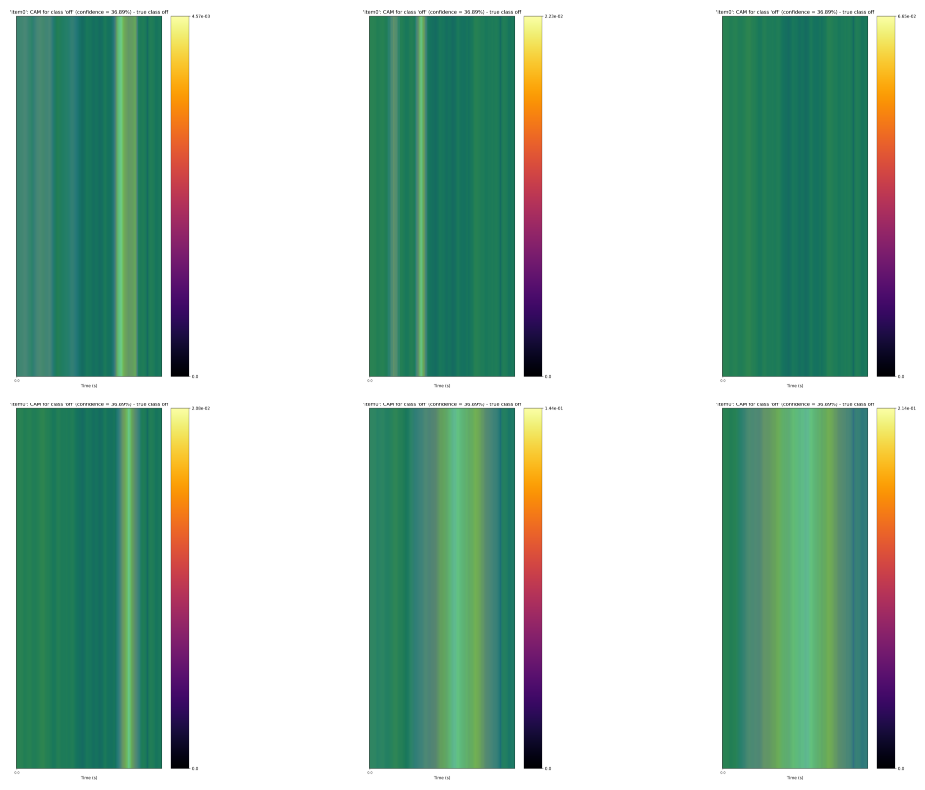

In [15]:
# "OFF"
images_to_show = sorted(Path(f"{xai_path}/CAMs/overlays/0-2/item1/").glob("*Grad*.png"))
show_image_grid(images_to_show)

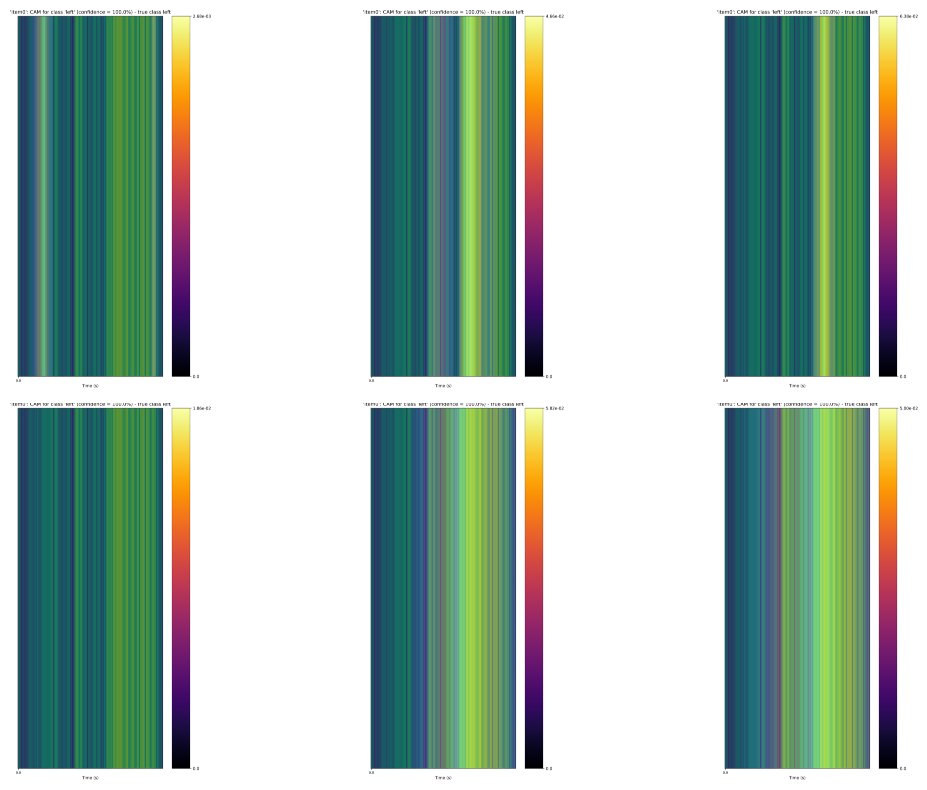

In [16]:
# "LEFT"
images_to_show = sorted(Path(f"{xai_path}/CAMs/overlays/0-2/item2/").glob("*Grad*.png"))
show_image_grid(images_to_show)

Comparamos con la línea de base anterior

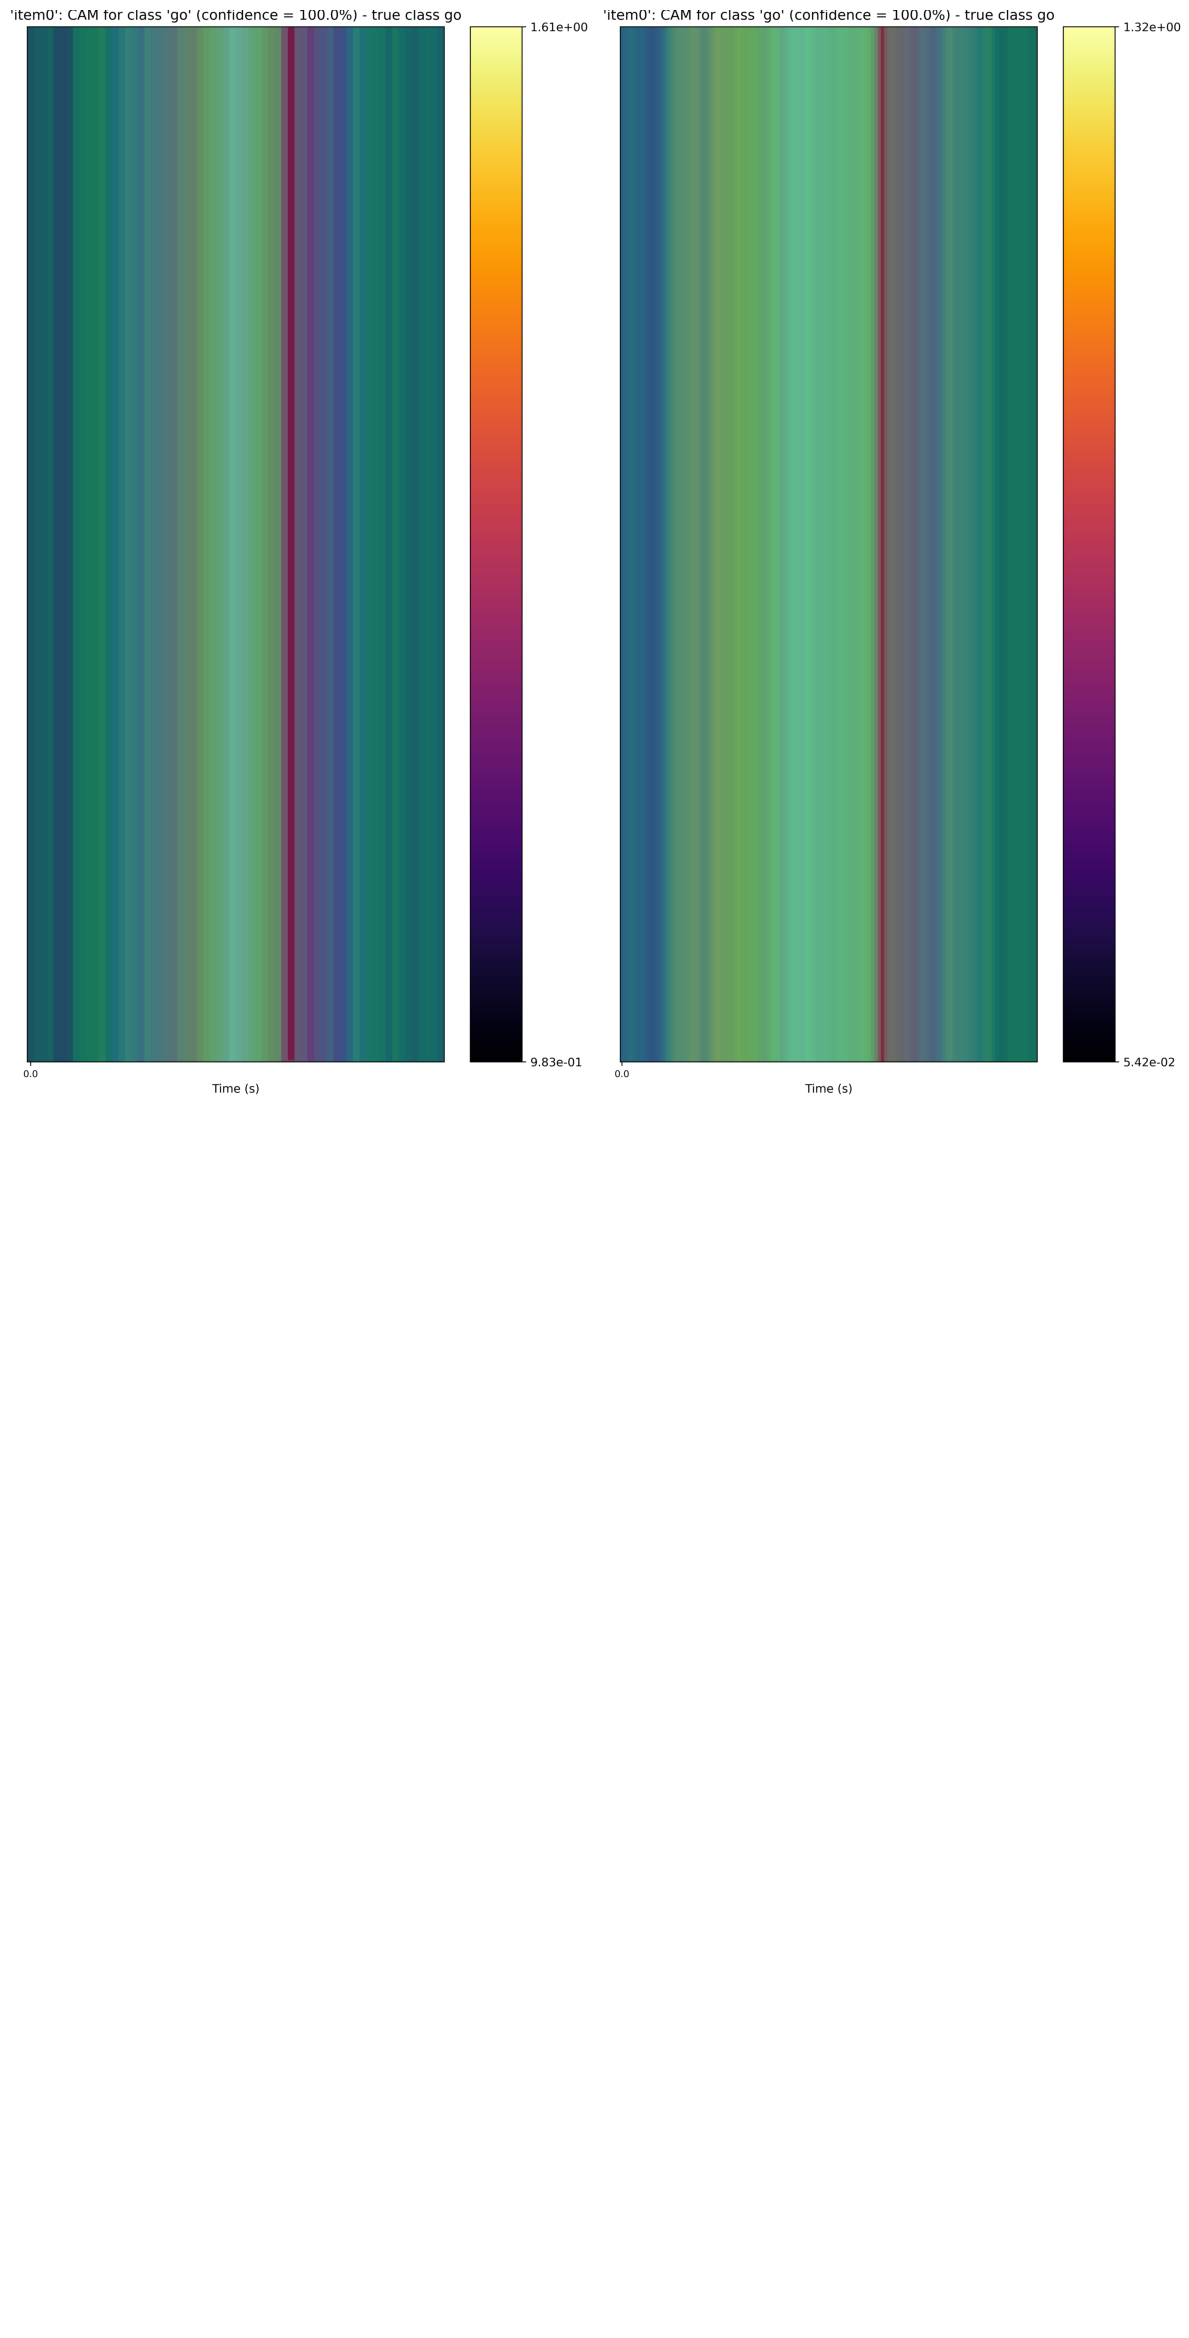

In [17]:
# CAM "GO"
cam_baseline = next(Path(f"/mnt/data/GSC/XAI/00-baseline_resnet18/CAMs/overlays/0-2/item0/").glob("*layer4_1_conv2*.png"), None)
cam_exp = next(Path(f"{xai_path}/CAMs/overlays/0-2/item0/").glob("*layer4_1_conv2*.png"), None)

images_to_show = [cam_baseline, cam_exp]
show_image_grid(images_to_show, cols=2, figsize=(12,24))

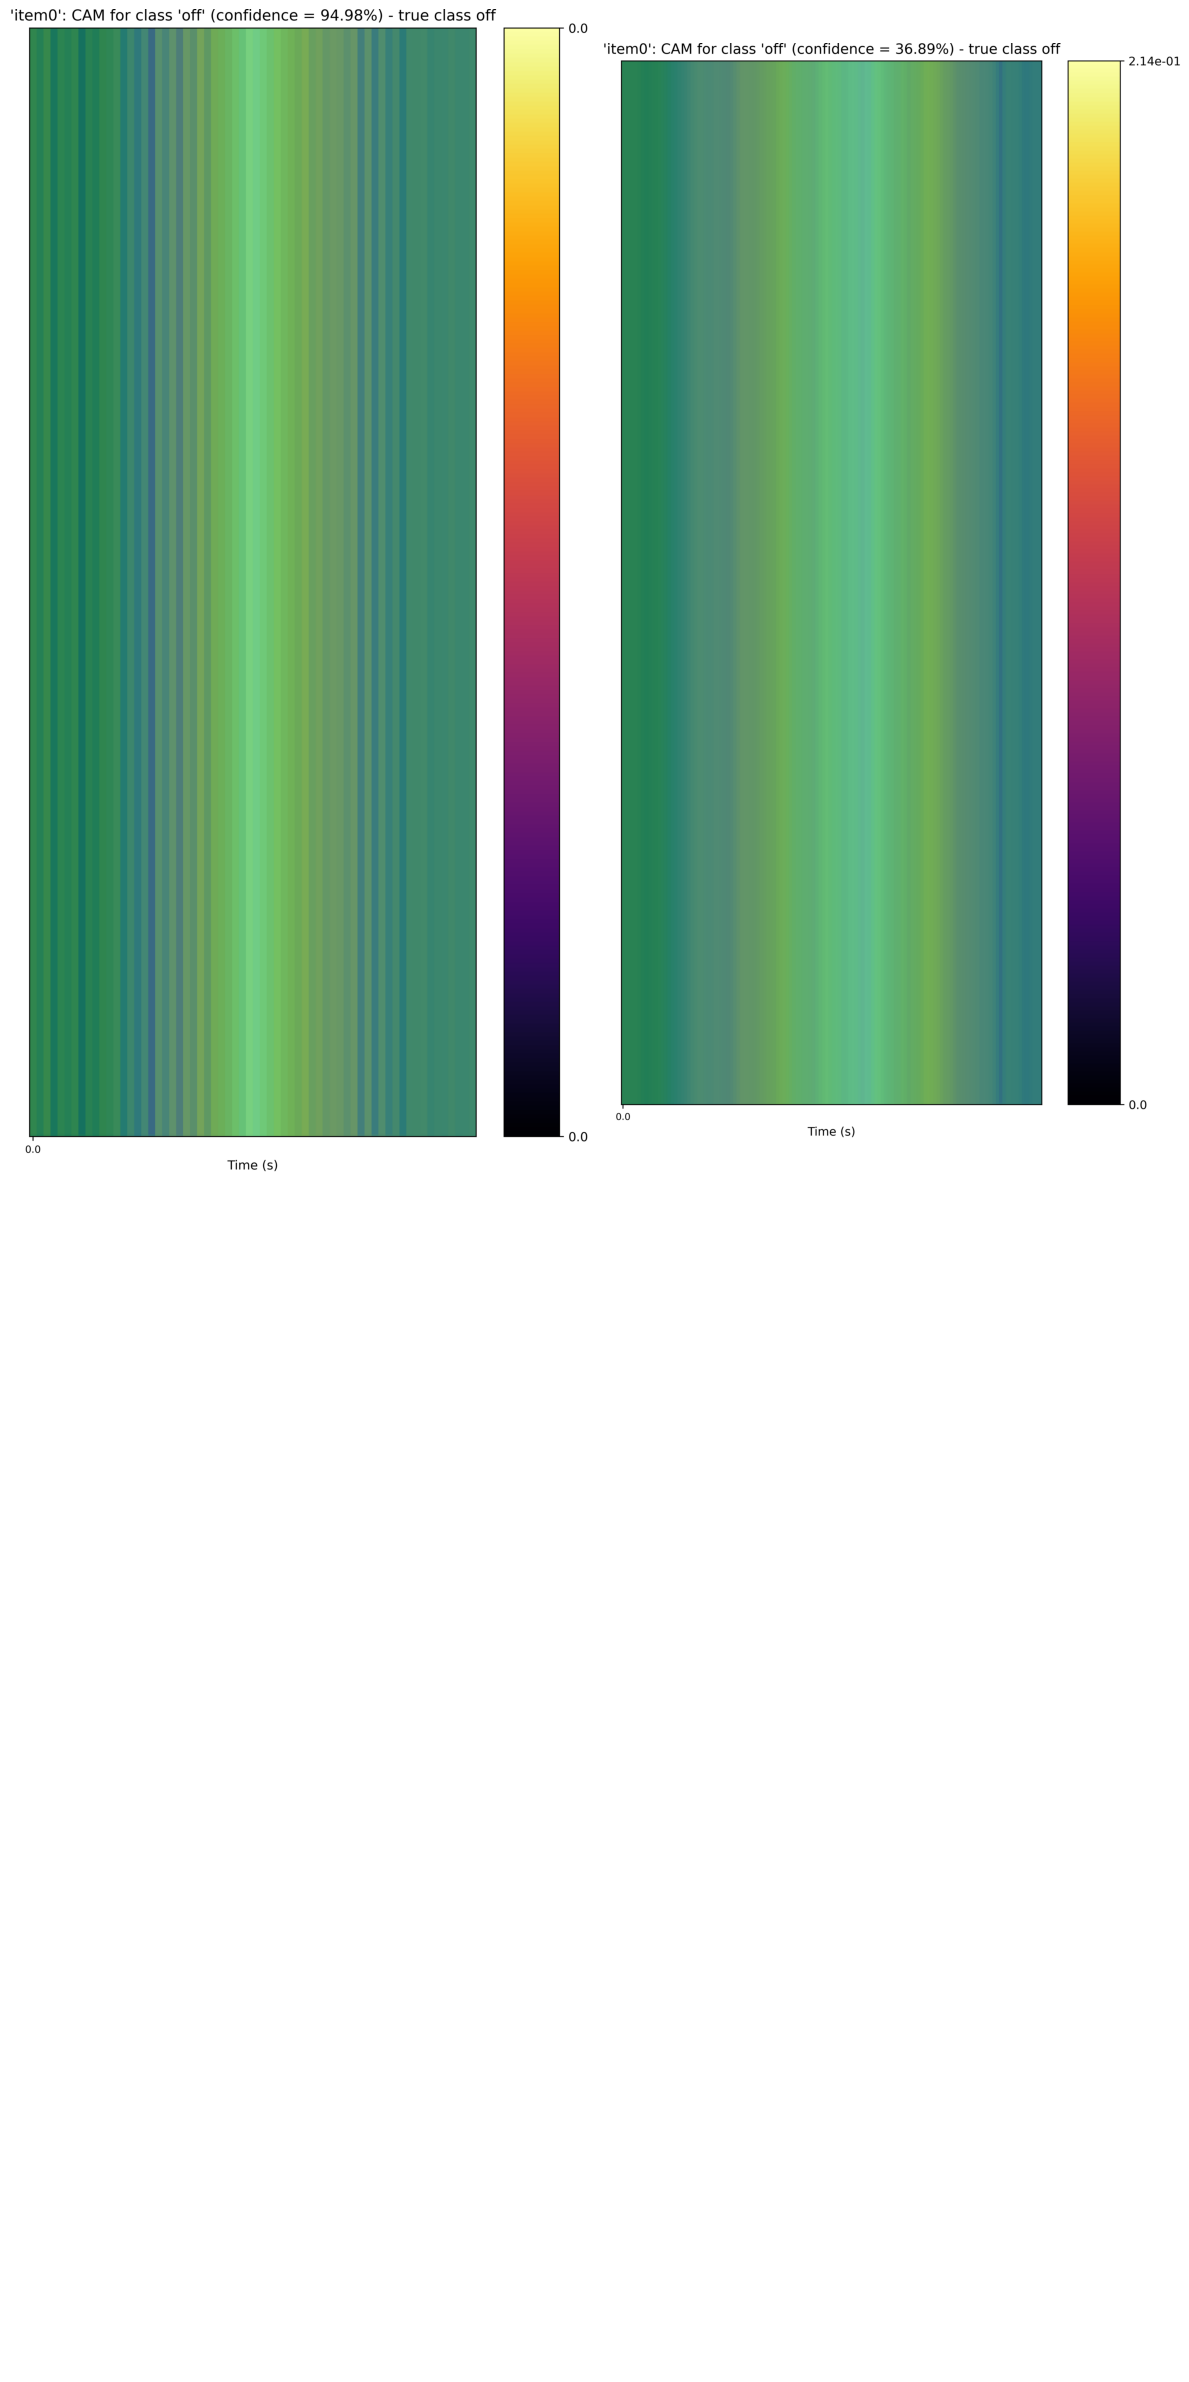

In [18]:
# CAM "OFF"
cam_baseline = next(Path(f"/mnt/data/GSC/XAI/00-baseline_resnet18/CAMs/overlays/0-2/item1/").glob("*layer4_1_conv2*.png"), None)
cam_exp = next(Path(f"{xai_path}/CAMs/overlays/0-2/item1/").glob("*layer4_1_conv2*.png"), None)

images_to_show = [cam_baseline, cam_exp]
show_image_grid(images_to_show, cols=2, figsize=(12,24))

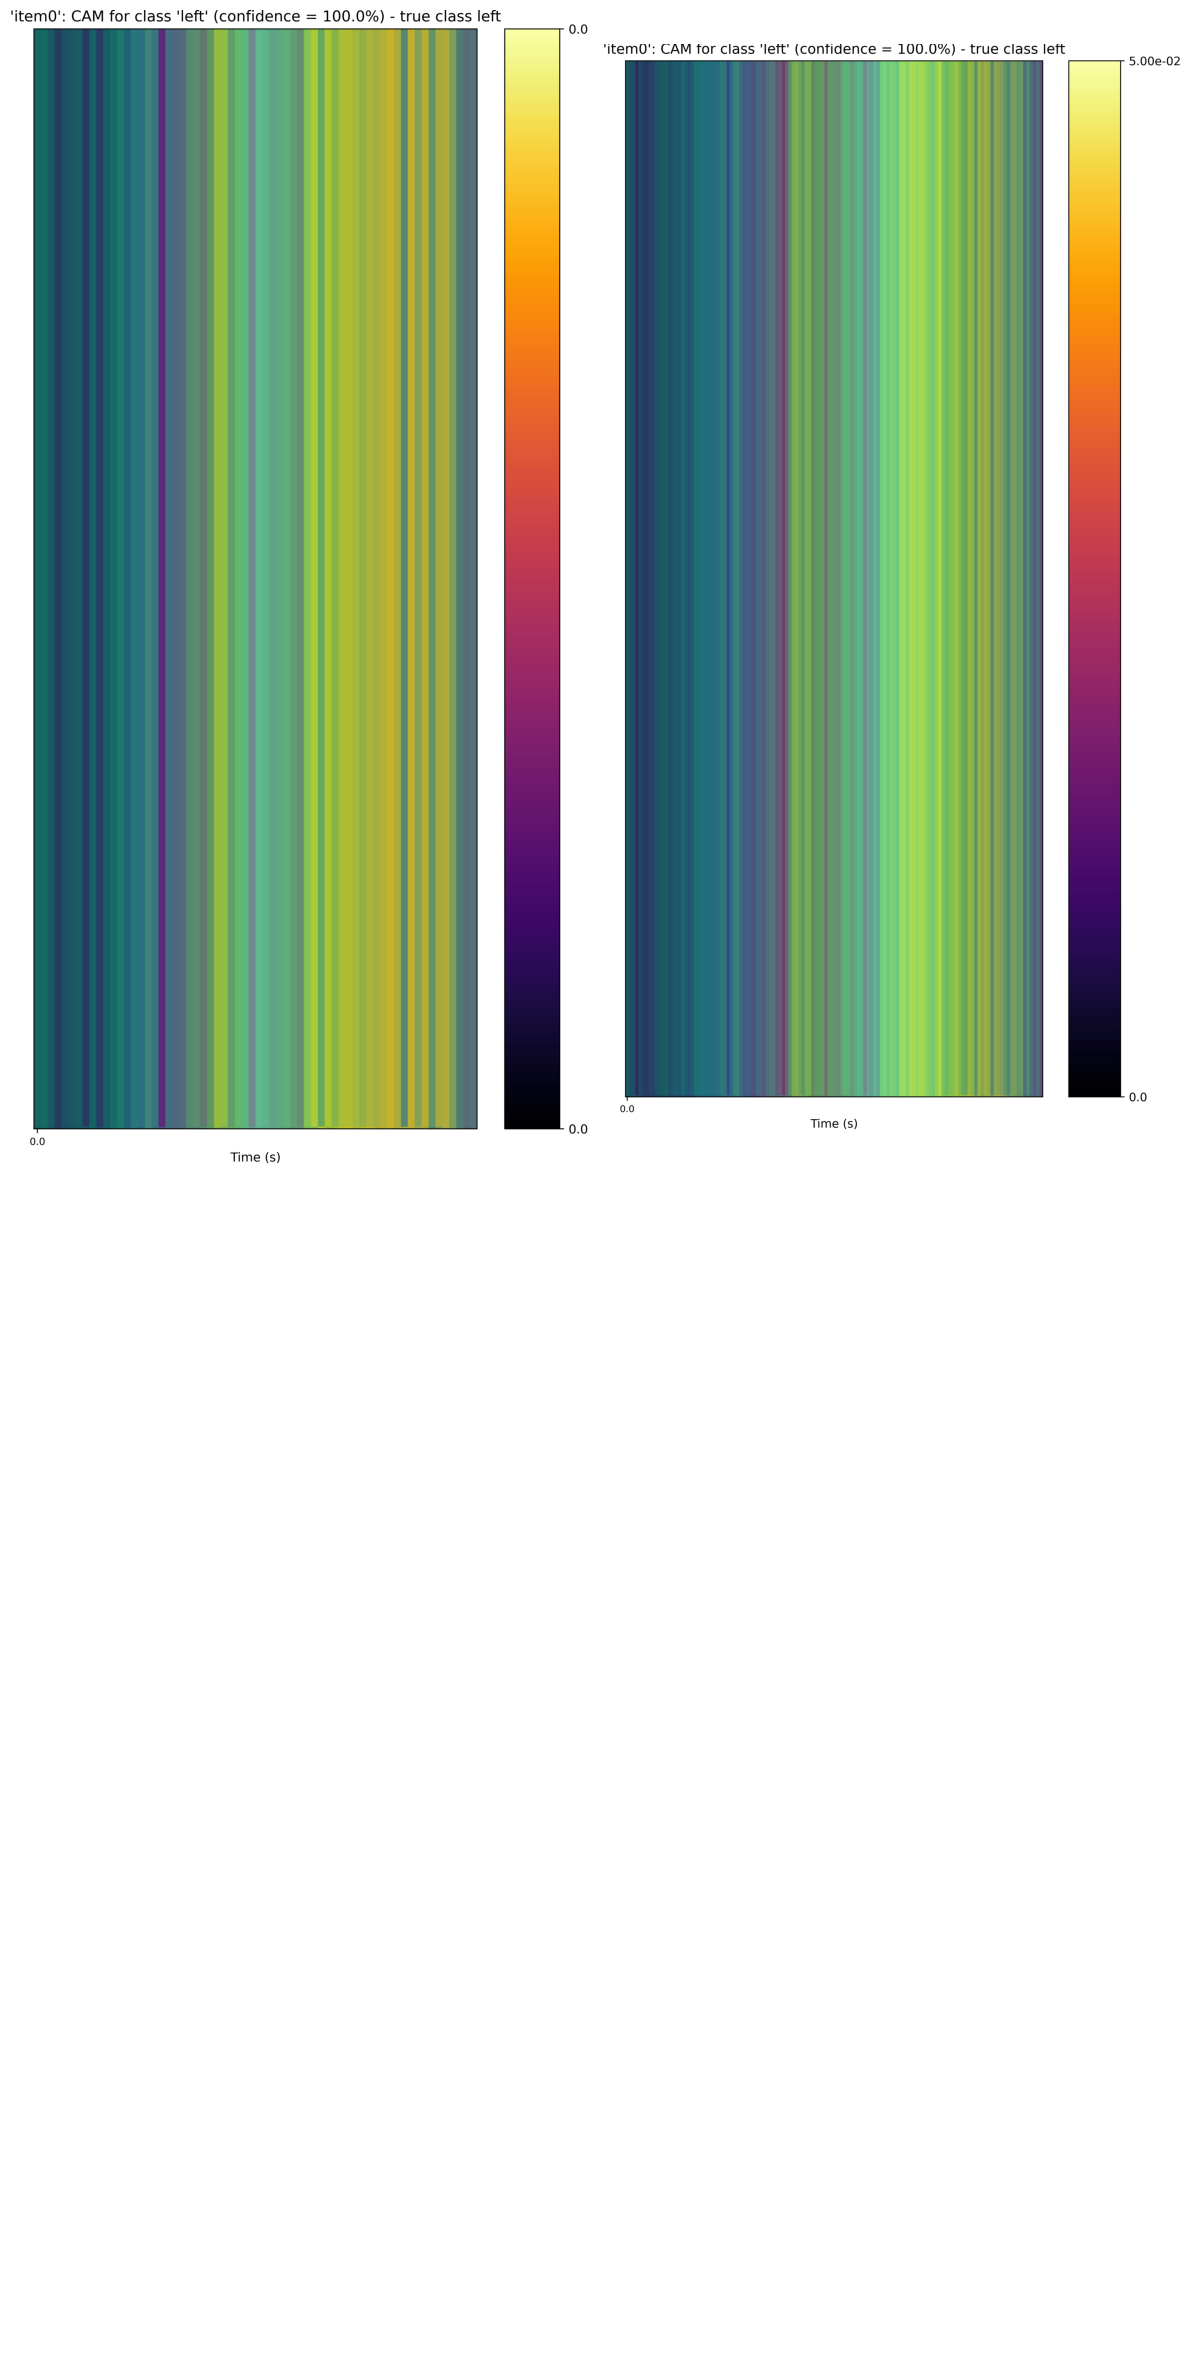

In [19]:
# CAM "LEFT"
cam_baseline = next(Path(f"/mnt/data/GSC/XAI/00-baseline_resnet18/CAMs/overlays/0-2/item2/").glob("*layer4_1_conv2*.png"), None)
cam_exp = next(Path(f"{xai_path}/CAMs/overlays/0-2/item2/").glob("*layer4_1_conv2*.png"), None)

images_to_show = [cam_baseline, cam_exp]
show_image_grid(images_to_show, cols=2, figsize=(12,24))

Se observa que los gradientes son más difusos en general con la nueva representación, pero la atención del modelo se centra fundamentalmente en las mismas componentes. la atención se concentra en una mayor 

Finalmente, vamos a estimar el coste de entrenamiento a partir del tiempo medio por epoch.

In [22]:
loaded_pt = torch.load(f"{final_path}/final_model.pt", map_location=DEVICE)
etimes = loaded_pt['history'].get('epoch_time')
avg_etime = sum(etimes)/len(etimes)
baseline_etime = 56.3
print("El coste en tiempo por epoch es de esta línea es", f"{avg_etime:.2f}")     
print("El coste en tiempo por epoch es de", f"{avg_etime/baseline_etime:.2f}", "veces el de la línea de base anterior.")     

El coste en tiempo por epoch es de esta línea es 155.78
El coste en tiempo por epoch es de 2.77 veces el de la línea de base anterior.
